In [72]:
import pandas as pd
import seaborn as sns

In [73]:
df=pd.read_excel("/content/marketing_campaign.xlsx")

In [74]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [76]:
df.isnull().sum()
"""we have very less percentage of missing values here in income col about lessthan 1 percent
   iam just thinking to drop
"""

'\nwe have very less percentage of missing values here in income col about lessthan 1 percent\niam just thinking to drop\n\n\n'

In [77]:
df.dropna(inplace=True)

In [78]:
df.isnull().sum() #nulls removed

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [79]:
df.duplicated().sum() # we dont have any duplicates

np.int64(0)

Feature Engineering

●	MntWines: Amount spent on wine in last 2 years

●	MntFruits: Amount spent on fruits in last 2 years

●	MntMeatProducts: Amount spent on meat in last 2 years

●	MntFishProducts: Amount spent on fish in last 2 years

●	MntSweetProducts: Amount spent on sweets in last 2 years

●	MntGoldProds: Amount spent on gold in last 2 years

so we have to sum them up to get the total sales of each person


In [80]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [81]:
columns_to_sum = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts','MntSweetProducts','MntGoldProds']


In [82]:
df['TotalSpent'] = df[columns_to_sum].sum(axis=1) # from this we can get total amont of a person purchased


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

●	AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

●	AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

●	AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

●	AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

●	AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

●	Response: 1 if customer accepted the offer in the last campaign, 0 otherwise


From this we can get to know this how many offers he accepted by summing them up

In [84]:
columns_to_sum1 = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4','AcceptedCmp5','Response']


In [85]:
df['TotalAcceptedOffers']=df[columns_to_sum1].sum(axis=1) # from this we can get to total no of offers he accepted in a new col

In [86]:
columns_to_sum2 = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']


In [87]:
df['TotalPurchases'] = df[columns_to_sum2].sum(axis=1) #from this we can get total no of purchases a new col

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [89]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'TotalSpent', 'TotalAcceptedOffers', 'TotalPurchases'],
      dtype='object')

Checking outliers for 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'


**iam just checking if there i any missleading data like Large values might distort patterns finding we need to vallidate those though capping or just remoeving from the data**

<Axes: xlabel='Recency'>

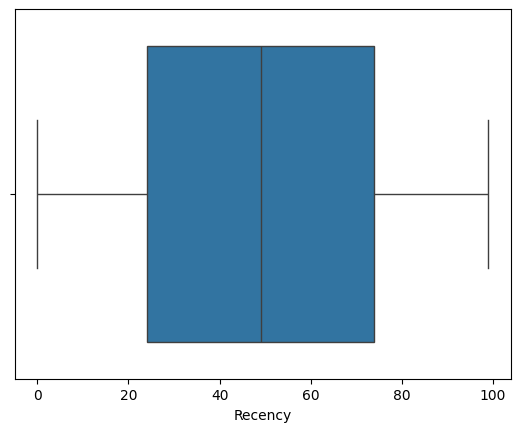

In [90]:
sns.boxplot(x=df["Recency"],data=df) # well we dont have any outlier in this col
#Recency: Number of days since customer's last purchase
#Some customers purchased very recently
#Some customers have been inactive for months

<Axes: xlabel='Income'>

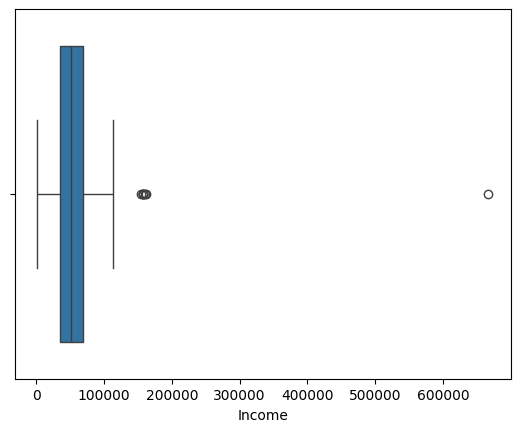

In [91]:
sns.boxplot(x=df["Income"],data=df) # we have to remove this outlier of income > 6000000
#and the income of each customers purchasing is mostly between this o to 1000000

In [92]:
df = df[df['Income'] <= 600000] #done handling outlier

<Axes: xlabel='MntWines'>

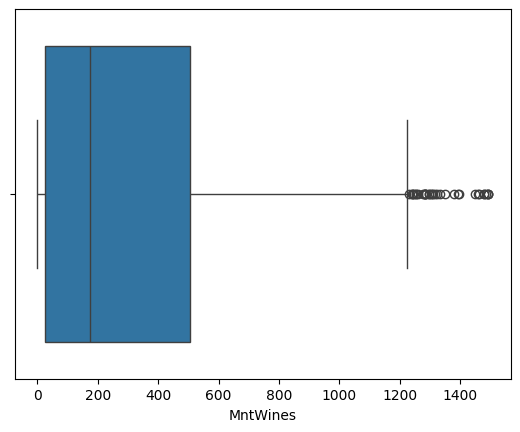

In [93]:
sns.boxplot(x=df['MntWines'],data=df) #we dont have extreme outliers so iam not going to do anything here
#and also  we might have costly wine in the store
#iam not going to handle this outliers


#mostly this wine costs are in between 100 to 450 and we can see way more outliers ranging from 1200 to 1450

<Axes: xlabel='MntFruits'>

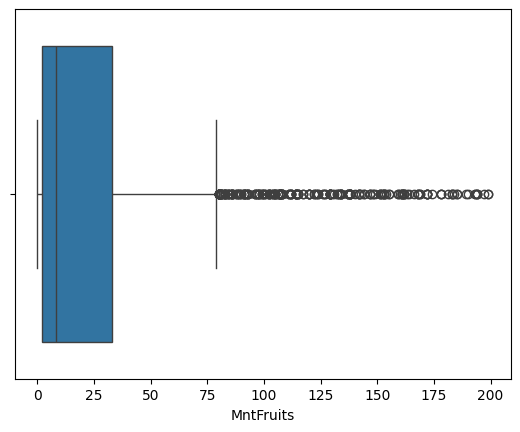

In [94]:
sns.boxplot(x=df['MntFruits'],data=df) #same here we might have costly fruits as well
#same here iam not going to handle this outlier
#here the fruits costs ranges from 10 to 200

<Axes: xlabel='MntMeatProducts'>

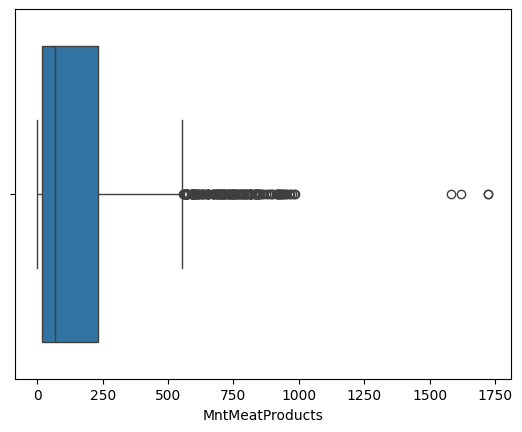

In [95]:
sns.boxplot(x=df['MntMeatProducts'],data=df) # we might have costly meat products
#here from yhis

<Axes: xlabel='MntFishProducts'>

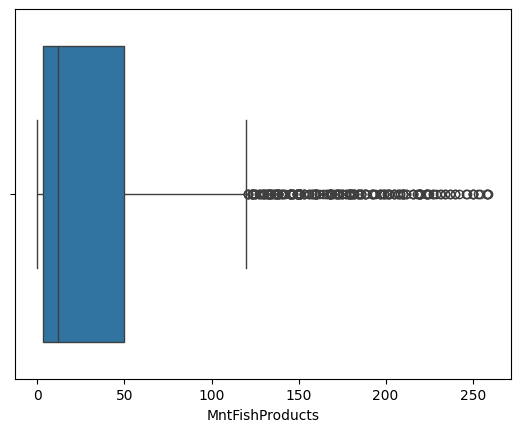

In [96]:
sns.boxplot(x=df['MntFishProducts'],data=df) # we might have costly FishProducts

<Axes: xlabel='MntSweetProducts'>

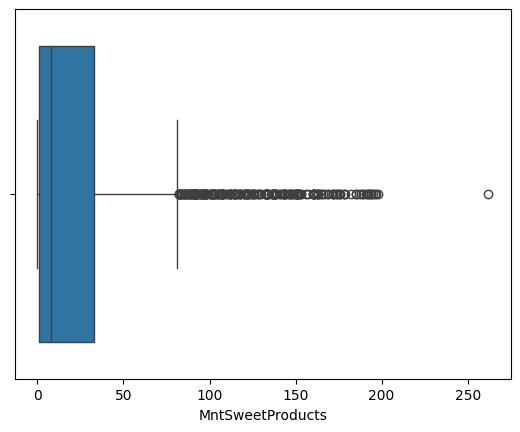

In [97]:
sns.boxplot(x=df['MntSweetProducts'],data=df) # we might have costly MntSweetProducts

<Axes: xlabel='MntGoldProds'>

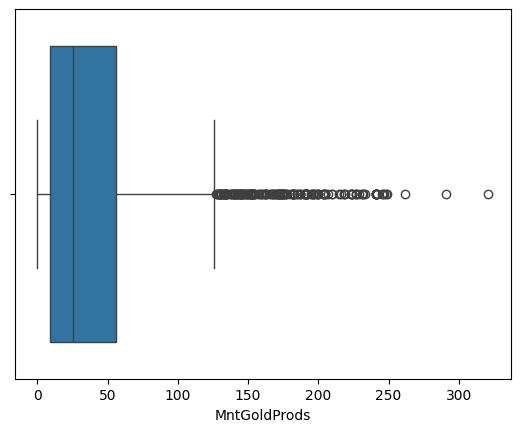

In [98]:
sns.boxplot(x=df['MntGoldProds'],data=df) # we might have costly GoldProds as well

<Axes: xlabel='NumDealsPurchases'>

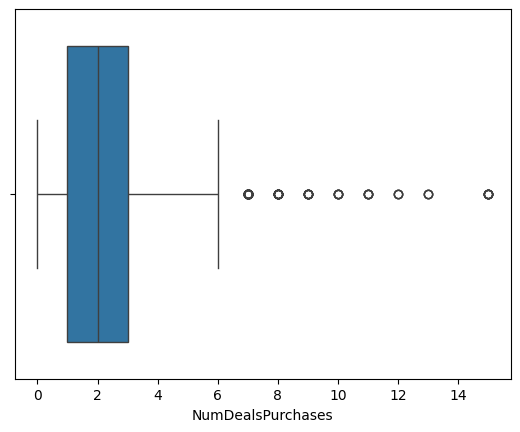

In [99]:
sns.boxplot(x=df['NumDealsPurchases'],data=df) # in discount time we can see no of purchases are increasing
#but only few customers are actually bying more prods in discounted price
#most of the poepl are buying 1 to 3 products in the discounted time

<Axes: xlabel='NumWebPurchases'>

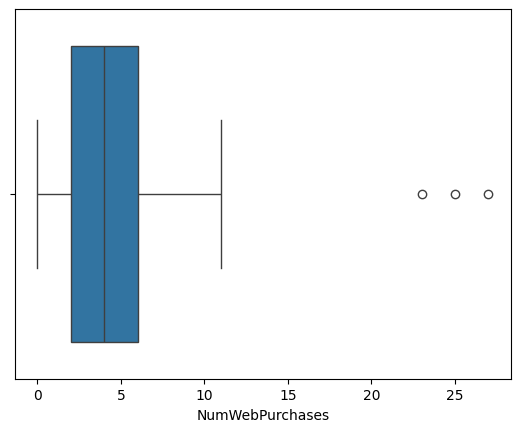

In [100]:
sns.boxplot(x=df['NumWebPurchases'],data=df) # From this plot we can get to know most customers make samll number of web purchases
#and but of them high online web purchases

#and most of people who are buying products in online web purchases ranging from 2 to 6 only

<Axes: xlabel='NumCatalogPurchases'>

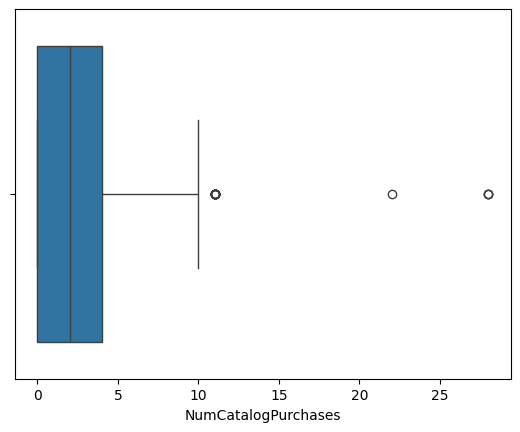

In [101]:
sns.boxplot(x=df['NumCatalogPurchases'],data=df)
#from this plot we can get to know that most customers rarely use catalog purchases
#only few of them are using catalog purchases heavily

<Axes: xlabel='NumStorePurchases'>

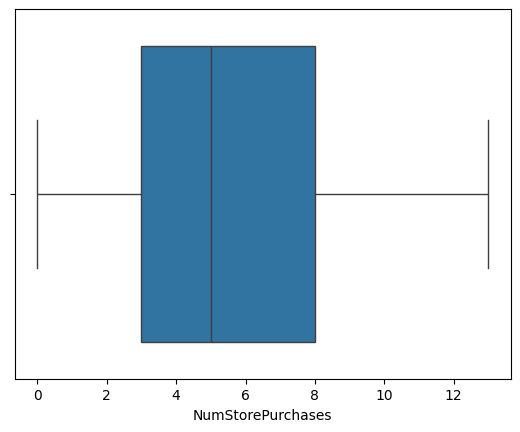

In [102]:
sns.boxplot(x=df['NumStorePurchases'],data=df)
#wo we can can see that most of the customers are actully buying from the store

Among all the buying modes store purchases are more stable and moderate no outliers

<Axes: xlabel='NumWebVisitsMonth'>

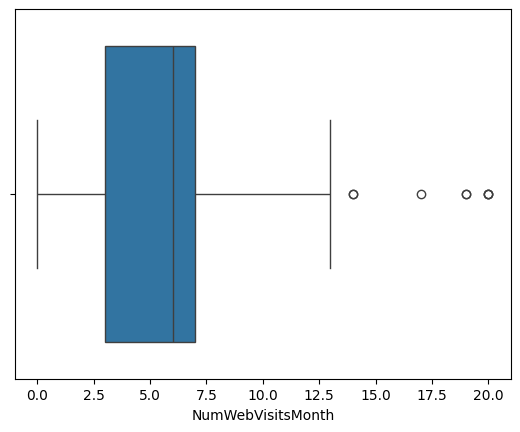

In [103]:
sns.boxplot(x=df['NumWebVisitsMonth'],data=df)
#from the plot we can get to know most of the customer are visiting companies website is only between 3 to 7.5 times only
#only few of customers usually visiting to website

<Axes: xlabel='Recency', ylabel='TotalSpent'>

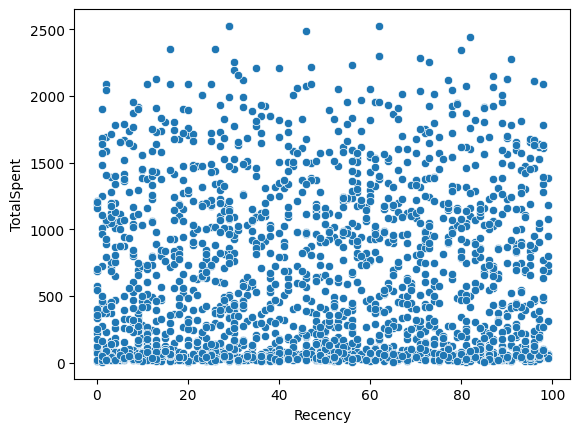

In [104]:
sns.scatterplot(x=df['Recency'],y=df['TotalSpent'],data=df)

In [105]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'TotalSpent', 'TotalAcceptedOffers', 'TotalPurchases'],
      dtype='object')

<Axes: xlabel='TotalPurchases', ylabel='TotalSpent'>

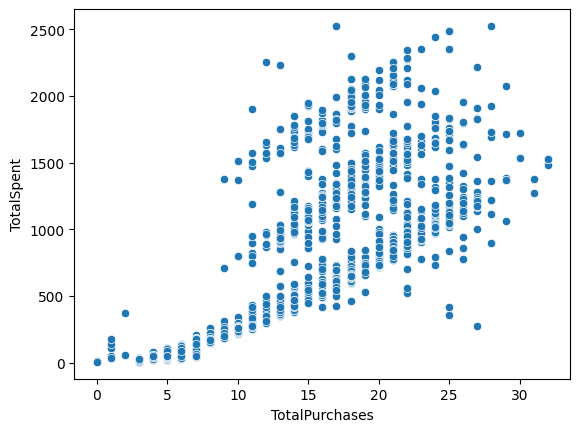

In [106]:
sns.scatterplot(x=df['TotalPurchases'],y=df['TotalSpent'],data=df)
# from this grpah we can get to know that as purchases increases and spending increases
#in this graph we can see that two people bought 25 prods under 500 and there is another person right there around 25 to 30 prods as well

Choosing features for modelling

we need only those features that describes customer behaviour

Year_Birth
Education
Marital_Status
Income
Kidhome
Teenhome

There actually explain customer details so we dont need them
our goal is to find customer patterns

In [109]:
print(df.Z_CostContact.value_counts())
print(df.Z_Revenue.value_counts())

Z_CostContact
3    2215
Name: count, dtype: int64
Z_Revenue
11    2215
Name: count, dtype: int64


i noticed Z_CostContact,Z_Revenue we have same data all along the data so these doesnot even matter in customer behavior
so iam dropping them

In [110]:
#dropping this two cols Z_CostContact,Z_Revenue
df= df.drop(['Z_CostContact', 'Z_Revenue'], axis=1)


<Axes: xlabel='Education', ylabel='count'>

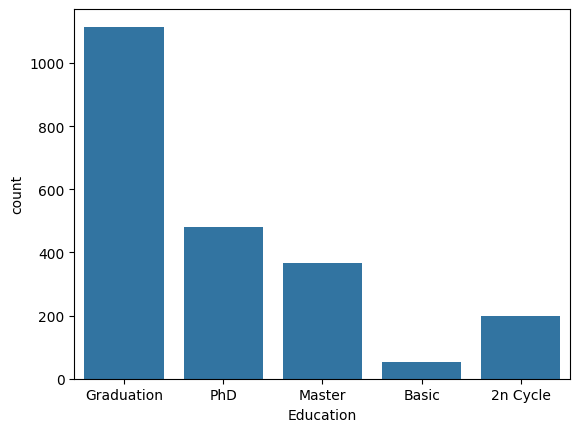

In [120]:
sns.countplot(x=df['Education'],data=df) # in this data so many customers are in graduate level of education

Marital_Status
Married     857
Together    572
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


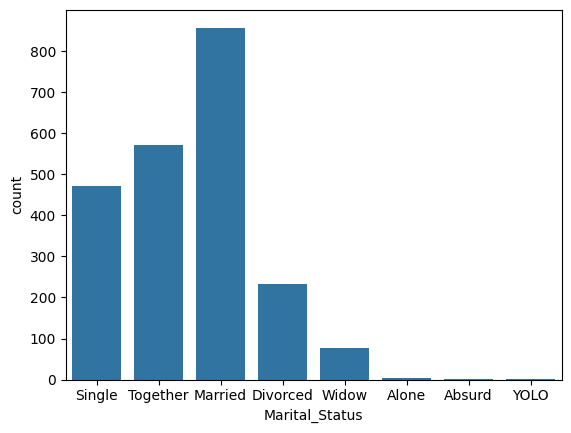

In [124]:
sns.countplot(x=df['Marital_Status'])
print(df.Marital_Status.value_counts())
#from this plot we can get to know that there are 800+ customers are married

selecting only feature that do matter in this customer behaviour

In [112]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'TotalSpent',
       'TotalAcceptedOffers', 'TotalPurchases'],
      dtype='object')